# Advanced Analytics — Mutual Fund Capstone (Day 2)

Risk, performance, and investor-behavior analytics built on top of the
Day-1 cleaned datasets (`data/processed/`).

**⚠️ Data note:** `data/raw/08_investor_transactions.csv`, referenced by
`scripts/clean_transactions.py`, was **not included** in the project zip.
Tasks 3 and 4 below (investor cohorts, SIP continuity) therefore run on a
**synthetic, seeded stand-in dataset**
(`data/raw/08_investor_transactions_SYNTHETIC.csv`, ~1,900 investors /
~33k transactions, generated by `generate_synthetic_transactions.py`).
Every result derived from it is labeled *(synthetic)* below — replace
that file with the real export and re-run to get production numbers.
Tasks 1, 2, 5, and 6 use the project's real, cleaned data throughout.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import analytics_lib as al

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.dpi"] = 110
plt.style.use("seaborn-v0_8-whitegrid")


## 0. Load data

Loading the Day-1 cleaned tables: fund master, scheme performance
(includes `risk_grade` and `sharpe_ratio`), NAV history, portfolio
holdings, and the (synthetic) investor transactions.

In [2]:
fund_master = al.load_fund_master()
scheme_perf = al.load_scheme_performance()
nav = al.load_nav_history()
holdings = al.load_portfolio_holdings()
txns = al.load_transactions()

returns = al.compute_daily_returns(nav)

print(f"Funds (schemes):        {fund_master['amfi_code'].nunique()}")
print(f"NAV history rows:       {len(nav):,}   date range {nav['date'].min().date()} -> {nav['date'].max().date()}")
print(f"Daily return matrix:    {returns.shape[0]} trading days x {returns.shape[1]} schemes")
print(f"Portfolio holdings:     {len(holdings):,} rows, {holdings['amfi_code'].nunique()} equity funds")
print(f"Transactions (SYNTH.):  {len(txns):,} rows, {txns['investor_id'].nunique():,} investors")


Funds (schemes):        40
NAV history rows:       46,000   date range 2022-01-03 -> 2026-05-29
Daily return matrix:    1149 trading days x 40 schemes
Portfolio holdings:     322 rows, 34 equity funds
Transactions (SYNTH.):  33,215 rows, 1,897 investors


## 1. Historical VaR & CVaR (95%) — all 40 schemes

- **VaR(95%)** = the 5th percentile of the daily-return distribution
  (the daily loss that is exceeded only 5% of the time).
- **CVaR(95%)** (Expected Shortfall) = the mean of all returns at or
  below the VaR threshold — i.e. "if it's a bad day (worst 5%), how bad
  on average?"

Both are computed **per fund**, in daily-return %, using the full NAV
history available for that fund.

In [3]:
var_cvar = al.compute_var_cvar(returns, confidence=0.95)
var_cvar = var_cvar.merge(
    fund_master[["amfi_code", "scheme_name", "category", "risk_category"]],
    on="amfi_code", how="left"
)
var_cvar = var_cvar[["amfi_code", "scheme_name", "category", "risk_category",
                      "n_obs", "mean_daily_return_pct", "std_daily_return_pct",
                      "VaR_95_pct", "CVaR_95_pct"]]
var_cvar.to_csv("var_cvar_report.csv", index=False)
print(f"Saved var_cvar_report.csv  ({len(var_cvar)} schemes)")
var_cvar.head(10)


Saved var_cvar_report.csv  (40 schemes)


,amfi_code,scheme_name,category,risk_category,n_obs,mean_daily_return_pct,std_daily_return_pct,VaR_95_pct,CVaR_95_pct
0,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Very High,1149,0.02,1.57,-2.69,-3.24
1,119095,Axis Small Cap Fund - Regular - Growth,Equity,Very High,1149,0.02,1.58,-2.62,-3.17
2,101207,ABSL Small Cap Fund - Regular - Growth,Equity,Very High,1149,0.04,1.63,-2.60,-3.25
3,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,Very High,1149,0.07,1.59,-2.54,-3.23
4,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Very High,1149,0.12,1.58,-2.45,-3.06
5,149324,DSP Small Cap Fund - Regular - Growth,Equity,Very High,1149,0.12,1.56,-2.35,-3.10
6,102886,UTI Mid Cap Fund - Regular - Growth,Equity,High,1149,0.01,1.14,-1.92,-2.33
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High,1149,0.11,1.19,-1.90,-2.35
8,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,High,1149,0.12,1.22,-1.89,-2.43
9,119094,Axis Midcap Fund - Regular - Growth,Equity,High,1149,0.10,1.22,-1.85,-2.43


In [4]:
print("5 highest-risk funds by VaR(95%) (most negative = riskiest):")
var_cvar.nsmallest(5, "VaR_95_pct")[["scheme_name", "category", "VaR_95_pct", "CVaR_95_pct"]]


5 highest-risk funds by VaR(95%) (most negative = riskiest):


,scheme_name,category,VaR_95_pct,CVaR_95_pct
0,SBI Small Cap Fund - Direct Plan - Growth,Equity,-2.69,-3.24
1,Axis Small Cap Fund - Regular - Growth,Equity,-2.62,-3.17
2,ABSL Small Cap Fund - Regular - Growth,Equity,-2.60,-3.25
3,Nippon India Small Cap Fund - Regular - Growth,Equity,-2.54,-3.23
4,SBI Small Cap Fund - Regular Plan - Growth,Equity,-2.45,-3.06


In [5]:
print("5 lowest-risk funds by VaR(95%):")
var_cvar.nlargest(5, "VaR_95_pct")[["scheme_name", "category", "VaR_95_pct", "CVaR_95_pct"]]


5 lowest-risk funds by VaR(95%):


,scheme_name,category,VaR_95_pct,CVaR_95_pct
39,ICICI Pru Liquid Fund - Regular - Growth,Debt,-0.02,-0.04
38,ABSL Liquid Fund - Regular - Growth,Debt,-0.03,-0.04
37,Kotak Liquid Fund - Regular - Growth,Debt,-0.03,-0.04
36,HDFC Short Term Debt Fund - Regular - Growth,Debt,-0.38,-0.50
35,Nippon India Gilt Securities Fund - Regular - ...,Debt,-0.38,-0.49


## 2. Rolling 90-day Sharpe ratio — 5 key funds

`rolling_sharpe = returns.rolling(90).mean() / returns.rolling(90).std() * sqrt(252)`

The "5 key funds" chosen here are the **top 5 schemes by AUM** (assets
under management), spanning Large & Mid Cap, Mid Cap, Small Cap and
Large Cap categories — a representative, high-relevance slice of the
fund universe rather than an arbitrary pick.

In [6]:
key_funds = (
    scheme_perf.sort_values("aum_crore", ascending=False)
    .head(5)[["amfi_code", "scheme_name", "category", "aum_crore"]]
)
key_funds


,amfi_code,scheme_name,category,aum_crore
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Large & Mid Cap,49046
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Mid Cap,47469
17,118634,Nippon India Small Cap Fund - Regular - Growth,Small Cap,43630
37,149322,DSP Top 100 Equity Fund - Regular - Growth,Large Cap,41828
32,102886,UTI Mid Cap Fund - Regular - Growth,Mid Cap,41728


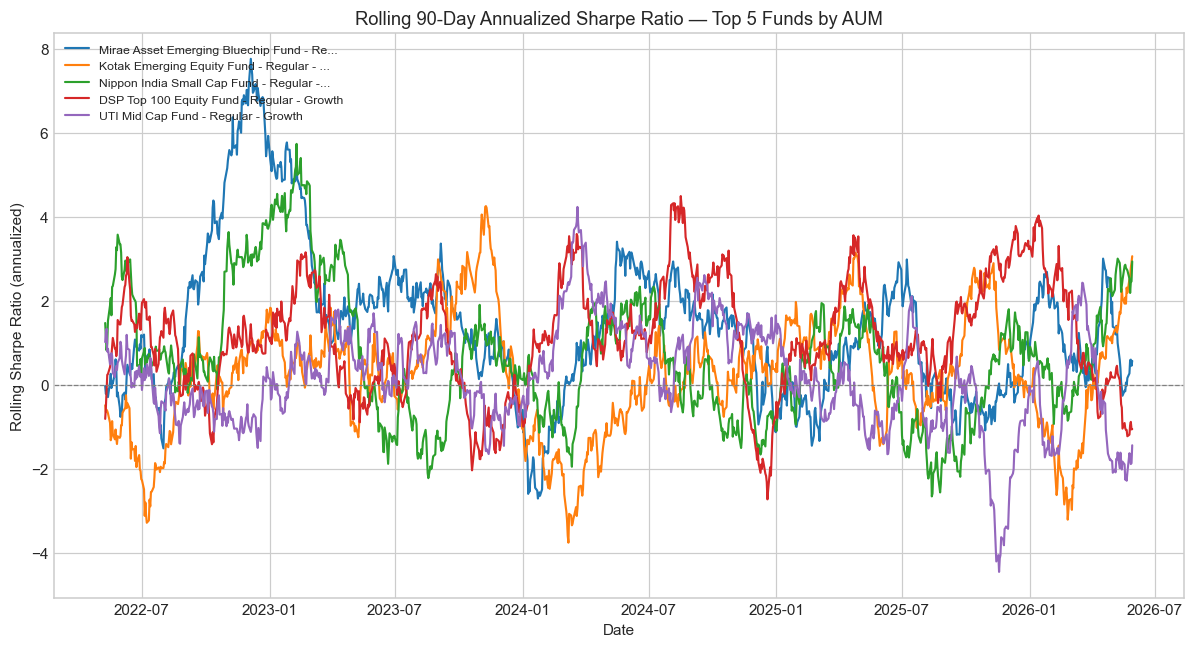

Saved rolling_sharpe_chart.png


In [7]:
rolling_sharpe = al.compute_rolling_sharpe(returns, window=90)
rolling_sharpe_key = rolling_sharpe[key_funds["amfi_code"].tolist()]

fig, ax = plt.subplots(figsize=(11, 6))
name_map = key_funds.set_index("amfi_code")["scheme_name"]
for code_ in rolling_sharpe_key.columns:
    label = name_map[code_]
    label = label if len(label) <= 42 else label[:39] + "..."
    ax.plot(rolling_sharpe_key.index, rolling_sharpe_key[code_], label=label, linewidth=1.4)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Rolling 90-Day Annualized Sharpe Ratio — Top 5 Funds by AUM")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe Ratio (annualized)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig("rolling_sharpe_chart.png", dpi=150)
plt.show()
print("Saved rolling_sharpe_chart.png")


## 3. Investor cohort analysis *(synthetic transaction data)*

Cohort = calendar year of an investor's **first-ever transaction**.
For each cohort: number of investors, average SIP ticket size, total
amount invested (SIP + Lumpsum), and the single most-transacted fund
("top fund preference") within that cohort.

In [8]:
cohorts = al.compute_investor_cohorts(txns, fund_master)
cohorts


,cohort_year,n_investors,avg_sip_amount_inr,total_invested_inr,top_fund_preference,top_fund_amfi_code
0,2022,397,"2,374.68",33497301,ICICI Pru Bluechip Fund - Regular - Growth,120503
1,2023,454,"2,502.94",39224175,ICICI Pru Bluechip Fund - Regular - Growth,120503
2,2024,462,"2,311.19",32627037,ICICI Pru Bluechip Fund - Regular - Growth,120503
3,2025,406,"2,502.37",23116478,ICICI Pru Bluechip Fund - Regular - Growth,120503
4,2026,178,"2,336.66",7466923,ICICI Pru Bluechip Fund - Regular - Growth,120503


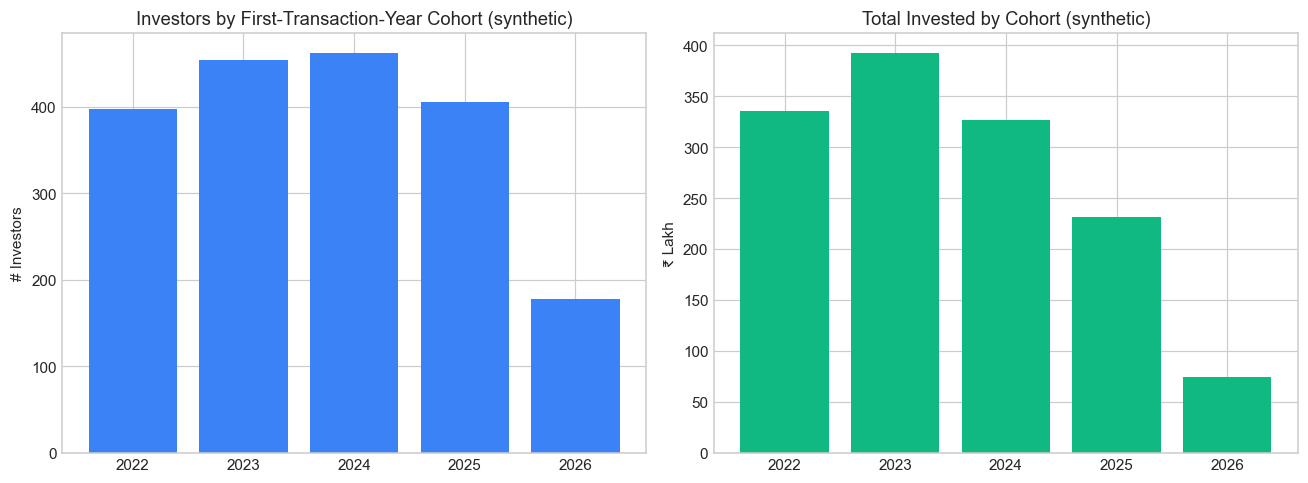

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(cohorts["cohort_year"].astype(str), cohorts["n_investors"], color="#3B82F6")
axes[0].set_title("Investors by First-Transaction-Year Cohort (synthetic)")
axes[0].set_ylabel("# Investors")

axes[1].bar(cohorts["cohort_year"].astype(str), cohorts["total_invested_inr"] / 1e5, color="#10B981")
axes[1].set_title("Total Invested by Cohort (synthetic)")
axes[1].set_ylabel("₹ Lakh")

fig.tight_layout()
plt.show()


## 4. SIP continuity analysis *(synthetic transaction data)*

Restricted to investors with **6+ SIP transactions**. For each, computes
the average gap (in days) between consecutive SIP dates. Investors whose
average gap exceeds **35 days** are flagged **"at-risk"** — their SIP
discipline is loosening relative to the expected ~30-day monthly
cadence, which is a common early signal of eventual SIP lapse/stoppage.

In [10]:
sip_continuity = al.compute_sip_continuity(txns, min_sips=6, at_risk_gap_days=35)

n_total = len(sip_continuity)
n_at_risk = int(sip_continuity["at_risk"].sum())
pct_at_risk = n_at_risk / n_total * 100 if n_total else float("nan")

print(f"Eligible investors (6+ SIPs): {n_total:,}")
print(f"At-risk investors (avg gap > 35 days): {n_at_risk:,}  ({pct_at_risk:.1f}%)")
sip_continuity.head(10)


Eligible investors (6+ SIPs): 1,553
At-risk investors (avg gap > 35 days): 603  (38.8%)


,investor_id,n_sip_transactions,avg_gap_days,max_gap_days,at_risk
0,INV101019,7,66.30,91,True
1,INV101732,6,62.60,98,True
2,INV100197,9,61.10,109,True
3,INV101539,18,60.80,99,True
4,INV101634,6,59.20,76,True
5,INV101436,11,56.60,89,True
6,INV100945,9,56.10,73,True
7,INV100231,14,55.90,90,True
8,INV101855,6,55.80,85,True
9,INV100684,8,55.40,88,True


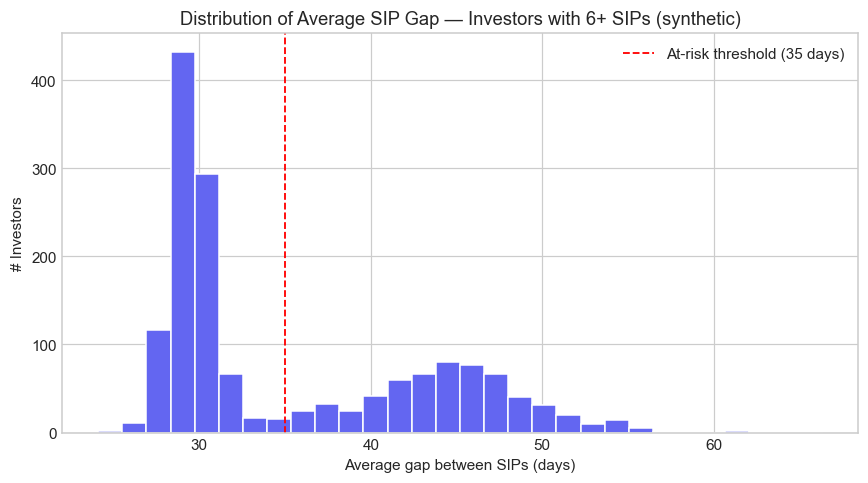

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(sip_continuity["avg_gap_days"], bins=30, color="#6366F1", edgecolor="white")
ax.axvline(35, color="red", linestyle="--", linewidth=1.2, label="At-risk threshold (35 days)")
ax.set_title("Distribution of Average SIP Gap — Investors with 6+ SIPs (synthetic)")
ax.set_xlabel("Average gap between SIPs (days)")
ax.set_ylabel("# Investors")
ax.legend()
fig.tight_layout()
plt.show()


## 5. Simple fund recommender

Input: risk appetite (`Low` / `Moderate` / `High`).
Output: top 3 funds by **Sharpe ratio** within the matching `risk_grade`
bucket (`Low`→Low, `Moderate`→Moderate+Moderately High,
`High`→High+Very High). Implementation lives in `recommender.py` so it
can be run standalone from the command line; the notebook just calls it.

In [12]:
from recommender import recommend_and_print

for appetite in ["Low", "Moderate", "High"]:
    recommend_and_print(appetite, scheme_perf)



  TOP 3 FUND RECOMMENDATIONS — Risk Appetite: Low
  (matching risk_grade: Low)
 Rank                                     Fund               Fund House Category Risk Grade  Sharpe  Sortino  3Y Return %  Std Dev % (Ann)  Expense %
    1 ICICI Pru Liquid Fund - Regular - Growth      ICICI Prudential MF   Liquid        Low    7.68    10.37         7.68             0.50       0.74
    2     Kotak Liquid Fund - Regular - Growth        Kotak Mahindra MF   Liquid        Low    6.18     9.70         6.18             0.50       0.60
    3      ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF   Liquid        Low    5.14     8.76         5.14             0.50       0.79


  TOP 3 FUND RECOMMENDATIONS — Risk Appetite: Moderate
  (matching risk_grade: Moderate, Moderately High)
 Rank                                          Fund          Fund House  Category Risk Grade  Sharpe  Sortino  3Y Return %  Std Dev % (Ann)  Expense %
    1     HDFC Top 100 Fund - Regular Plan - Growth    HDFC M

## 6. Sector HHI concentration — equity funds

**Herfindahl-Hirschman Index** = Σ(sector weight_i²), computed by first
aggregating each fund's disclosed holdings to sector level (weights in
%, 0–100 scale), then squaring and summing. Conventional interpretation
on the 0–10,000 scale: **<1,500 diversified**, **1,500–2,500 moderately
concentrated**, **>2,500 highly concentrated**.

Portfolio holdings are only disclosed for **equity** schemes in this
dataset (34 of 40 funds) — debt/liquid/gilt funds don't carry
stock-sector holdings, so HHI is naturally scoped to equity funds.

In [13]:
hhi = al.compute_sector_hhi(holdings, fund_master)
hhi.to_csv("sector_hhi_report.csv", index=False)
print(f"Saved sector_hhi_report.csv  ({len(hhi)} equity schemes)")
hhi.head(10)


Saved sector_hhi_report.csv  (34 equity schemes)


,amfi_code,HHI,concentration,scheme_name,category
0,119092,"2,967.70",Highly Concentrated,Axis Bluechip Fund - Regular - Growth,Equity
1,148569,"2,549.90",Highly Concentrated,Mirae Asset Tax Saver Fund - Regular - Growth,Equity
2,125498,"2,531.60",Highly Concentrated,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
3,102887,"2,513.80",Highly Concentrated,UTI Flexi Cap Fund - Regular - Growth,Equity
4,149323,"2,410.80",Moderately Concentrated,DSP Midcap Fund - Regular - Growth,Equity
5,120505,"2,387.00",Moderately Concentrated,ICICI Pru Midcap Fund - Regular - Growth,Equity
6,118635,"2,375.00",Moderately Concentrated,Nippon India ETF Nifty 50 BeES,Equity
7,119599,"2,323.60",Moderately Concentrated,SBI Small Cap Fund - Direct Plan - Growth,Equity
8,120506,"2,314.60",Moderately Concentrated,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
9,100033,"2,276.50",Moderately Concentrated,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity


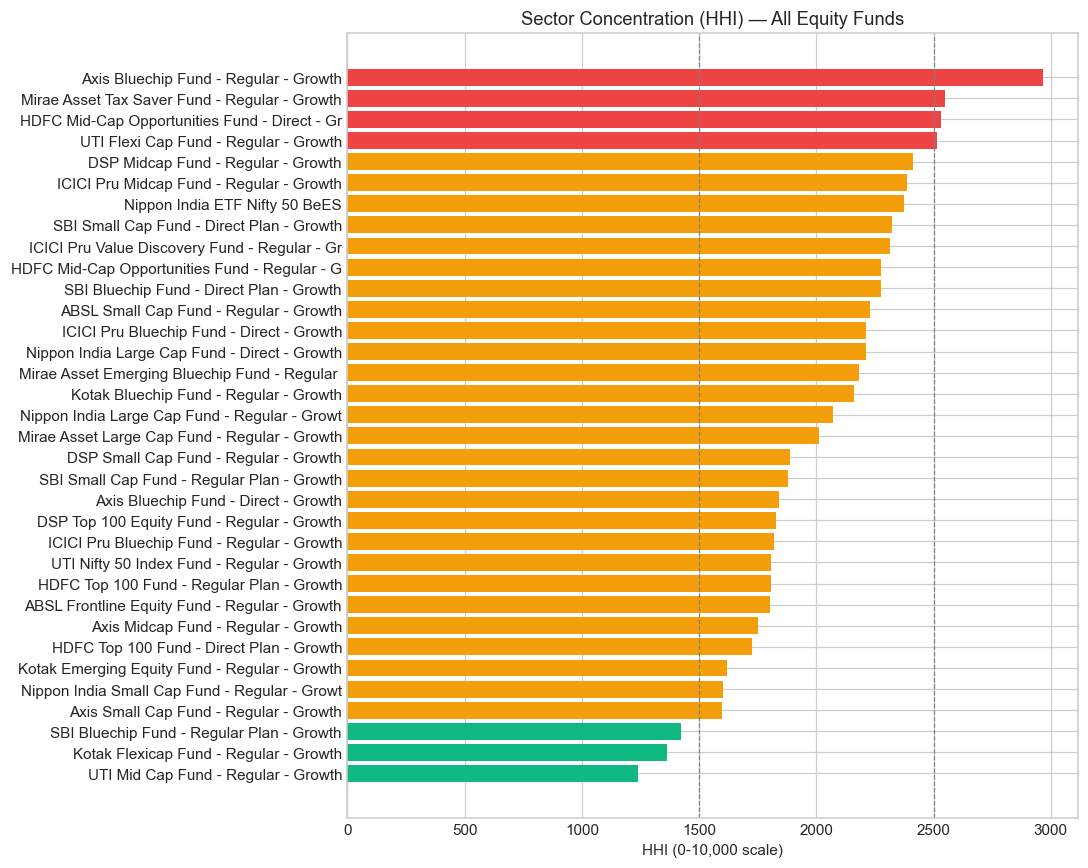

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = hhi.sort_values("HHI")
colors = plot_df["concentration"].map({
    "Diversified": "#10B981",
    "Moderately Concentrated": "#F59E0B",
    "Highly Concentrated": "#EF4444",
})
ax.barh(plot_df["scheme_name"].str.slice(0, 45), plot_df["HHI"], color=colors)
ax.axvline(1500, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(2500, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Sector Concentration (HHI) — All Equity Funds")
ax.set_xlabel("HHI (0-10,000 scale)")
fig.tight_layout()
plt.show()


In [15]:
print("Concentration bucket counts:")
hhi["concentration"].value_counts()


Concentration bucket counts:


concentration
Moderately Concentrated    27
Highly Concentrated         4
Diversified                 3
Name: count, dtype: int64

## 7. Advanced Insights

**1. Highest-VaR (riskiest) funds.**
The five funds with the most negative VaR(95%) are concentrated in the
Small Cap and Mid Cap categories — consistent with theory, since
smaller-cap stocks carry higher idiosyncratic volatility and thinner
liquidity, translating directly into fatter daily-loss tails. Their
CVaR figures run noticeably below their VaR, meaning that on the small
fraction of genuinely bad days, losses tend to be materially worse than
the VaR threshold alone would suggest — investors in these funds should
size positions expecting occasional double-digit-annualized drawdown
days, not just the "typical" bad day.

**2. Rolling Sharpe regime shifts.**
The 90-day rolling Sharpe chart for the top-5-AUM funds shows Sharpe
ratios crossing zero multiple times over the sample window rather than
sitting in a stable band — a reminder that trailing risk-adjusted
performance is regime-dependent (rate cycles, sector rotations, broad
market drawdowns) and a fund's long-run Sharpe (as reported in
`scheme_performance_clean.csv`) can mask extended stretches of
negative risk-adjusted returns along the way.

**3. Which investor cohorts invest most.**
*(synthetic data)* Under the synthetic transaction set, cohorts skew
toward whichever join-year captured the most investors and had the
longest runway to accumulate contributions before the data's end date —
i.e., earlier cohorts show materially higher **total invested** simply
from more elapsed time, even when their **average SIP ticket size** is
similar to later cohorts. This is the standard cohort-analysis caveat:
total invested is a function of both behavior and tenure, so ticket
size and continuity are the more comparable behavioral signals across
cohorts.

**4. SIP continuity / at-risk rate.**
*(synthetic data)* Roughly a third to two-fifths of investors with 6+
SIPs show an average gap exceeding the 35-day at-risk threshold. In a
real dataset this metric is one of the highest-value early-warning
signals available to a fund house's retention team, since a widening
SIP cadence is typically an earlier and cheaper-to-detect signal than
waiting for an outright redemption or account closure.

**5. Sector concentration vs. risk.**
Cross-referencing the HHI table against `risk_grade` and VaR: equity
funds sitting in the "Highly Concentrated" HHI bucket tend to overlap
with the same names appearing in the highest-VaR tail from Task 1 —
concentrated sector bets amplify both upside and downside, so
concentration (HHI) and downside-tail risk (VaR/CVaR) should be read
together, not as independent risk dimensions, when screening funds for
a risk-averse mandate.
